<a href="https://colab.research.google.com/github/kkokay07/LLM_adaptation/blob/main/Transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creator: Dr. KANAKA K. K.
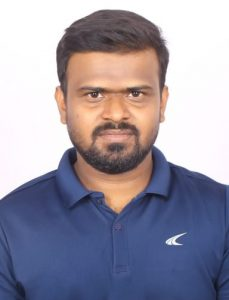

PhD, ARS  
Scientist

School of Bioinformatics and Computional Biology

ICAR-Indian Institute of Agricultural Biotechnology, Ranchi, Jharkhand.

Spy on me at :)  
[Google Scholar](https://scholar.google.com/citations?hl=en&user=0dQ7Sf8AAAAJ&view_op=list_works);    [ResearchGate](https://www.researchgate.net/profile/Kanaka-K-K/research);    [Website](https://iiab.icar.gov.in/staff/dr-kanaka-k-k/)

## 📘 Source

Natural Language Processing with Transformers  
Lewis Tunstall, Leandro von Werra, Thomas Wolf  
O’Reilly Media  

https://www.oreilly.com/library/view/natural-language-processing/9781098136789/

# 🔁 Practical 3: Transfer Learning with BERT
### Fundamentals of Generative AI — Hands-On Workshop

---

## 📋 What You'll Learn
1. What is Transfer Learning and the pre-train → fine-tune paradigm
2. BERT architecture overview
3. Adding a task-specific classification head to BERT
4. Frozen vs Unfrozen layers experiment
5. Fine-tuning BERT for sentiment classification
6. Evaluating and visualizing attention weights
7. Inference on custom text

**Model Used:** `bert-base-uncased` (~440MB) — works on Colab Free T4 GPU

---

> ⚠️ **Before starting:** Go to `Runtime → Change runtime type → T4 GPU`

---
## 🧠 Concept: Transfer Learning in NLP

```
PHASE 1: PRE-TRAINING (done by Google/Meta — millions of GPU hours)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Huge unlabeled text corpus → Train BERT → Learned language representations

PHASE 2: FINE-TUNING (what WE do — minutes on free GPU!)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Pre-trained BERT + Task head → Train on small labeled dataset → Task model

ANALOGY: Like hiring an educated person (BERT) and training them
  for your specific job (crop sentiment analysis) — much faster
  than educating them from scratch!
```

## 🔧 Step 1: Install & Import

In [ ]:
!pip install transformers datasets scikit-learn seaborn -q
print('✅ Libraries installed!')

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    BertModel,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'🖥️  Device: {device}')
if device == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

---
## 📚 Step 2: Create Agricultural Sentiment Dataset

Task: Classify agricultural/research texts as **Positive**, **Negative**, or **Neutral**

In [ ]:
# Agricultural domain sentiment dataset
# Labels: 0=Negative, 1=Neutral, 2=Positive

texts = [
    # POSITIVE (label=2)
    ("The new wheat variety showed excellent yield improvement across all trial locations.", 2),
    ("CRISPR technology successfully eliminated the disease susceptibility gene in rice.", 2),
    ("Farmers reported 40% higher income after adopting the improved seed variety.", 2),
    ("The deep learning model achieved 98% accuracy in detecting plant diseases.", 2),
    ("Transfer learning significantly reduced the training time for the crop model.", 2),
    ("The drought-tolerant maize variety performed exceptionally well during water stress.", 2),
    ("Biofertilizer application led to significant improvement in soil health and crop yield.", 2),
    ("The research breakthrough enables faster development of pest-resistant crop varieties.", 2),
    ("Precision irrigation resulted in 35% water savings without any yield reduction.", 2),
    ("The AI model successfully predicted crop disease outbreak two weeks in advance.", 2),
    ("Gene editing produced a rice variety with superior nutritional profile and yield.", 2),
    ("The new fungicide showed remarkable efficacy against wheat rust disease in field trials.", 2),
    ("Soil carbon sequestration increased by 25% after three years of improved management.", 2),
    ("The participatory breeding program resulted in farmer-preferred varieties being released.", 2),
    ("Machine learning predicted groundwater levels with 92% accuracy across all test sites.", 2),

    # NEGATIVE (label=0)
    ("The drought destroyed more than 60% of the kharif crops in the region this year.", 0),
    ("Pest infestation severely damaged the standing crops causing enormous economic losses.", 0),
    ("The model failed to generalize to unseen crop varieties and showed poor performance.", 0),
    ("Climate change is causing unprecedented crop failures across multiple agricultural zones.", 0),
    ("The new fertilizer treatment showed no significant improvement and caused soil degradation.", 0),
    ("Heavy rainfall led to widespread flooding and complete destruction of paddy fields.", 0),
    ("The deep learning model collapsed during training due to vanishing gradient problem.", 0),
    ("Overuse of pesticides has severely damaged beneficial insect populations in farms.", 0),
    ("Soil erosion has degraded 40% of agricultural land in the watershed area.", 0),
    ("The wheat rust epidemic spread rapidly destroying the entire crop in three districts.", 0),
    ("Transfer learning failed when source and target domains were too different in this study.", 0),
    ("Excessive nitrogen application resulted in groundwater contamination and yield reduction.", 0),
    ("The gene edited variety showed unexpected off-target effects and had to be withdrawn.", 0),
    ("Crop simulation models predicted severe food insecurity due to warming temperatures.", 0),
    ("The irrigation system breakdown caused irreversible damage to the standing cotton crop.", 0),

    # NEUTRAL (label=1)
    ("The study used BERT model to classify agricultural research abstracts into categories.", 1),
    ("ICAR released three new varieties of chickpea for the rabi season this year.", 1),
    ("The experiment was conducted across twelve locations spanning three agro-climatic zones.", 1),
    ("Genome sequencing of the wild rice accession was completed using Illumina platform.", 1),
    ("The dataset contained 5000 annotated images of crop leaves collected from field surveys.", 1),
    ("RNA was extracted from root samples and sequenced using next-generation sequencing.", 1),
    ("Soil samples were collected from 0-30 cm depth at fortnightly intervals during the season.", 1),
    ("The trial included 50 genotypes evaluated across multiple environments for yield stability.", 1),
    ("Leaf area index was measured using a canopy analyzer at weekly intervals during growth.", 1),
    ("The training dataset was split into 80% training and 20% validation sets randomly.", 1),
    ("A convolutional neural network with five layers was used for leaf disease classification.", 1),
    ("Fertilizer was applied at the rate recommended by the state agriculture department.", 1),
    ("The research was conducted over three consecutive kharif seasons from 2022 to 2024.", 1),
    ("GWAS analysis identified twelve significant SNP markers on chromosomes 3, 7, and 11.", 1),
    ("The model was trained for 100 epochs with a batch size of 32 on a single GPU.", 1),
]

# Separate texts and labels
all_texts = [t for t, l in texts]
all_labels = [l for t, l in texts]

label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
label_colors = {0: '#e74c3c', 1: '#95a5a6', 2: '#2ecc71'}

print(f'✅ Dataset created: {len(texts)} samples')
print(f'   Positive: {all_labels.count(2)} samples')
print(f'   Neutral:  {all_labels.count(1)} samples')
print(f'   Negative: {all_labels.count(0)} samples')

# Plot distribution
plt.figure(figsize=(6, 3))
counts = [all_labels.count(i) for i in range(3)]
bars = plt.bar(['Negative', 'Neutral', 'Positive'], counts,
               color=['#e74c3c', '#95a5a6', '#2ecc71'], edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, str(count), ha='center')
plt.title('Dataset Label Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

- **`[t for t, l in texts]`** — list comprehension unpacking each tuple `("sentence", label)` → extracts just the text

- **`[l for t, l in texts]`** — same but extracts just the label integer

- **`label_names / label_colors`** — dictionaries mapping integer labels to display strings and hex colours

- **`all_labels.count(2)`** — counts how many times `2` appears in the list

---
## 🛠️ Step 3: Tokenization & Dataset Class

In [ ]:
# Load BERT tokenizer
print('⏳ Loading BERT tokenizer...')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print('✅ Tokenizer loaded!')

# Demonstrate tokenization
sample = "CRISPR technology improved crop yield significantly."
tokens = tokenizer.tokenize(sample)
token_ids = tokenizer.encode(sample)
print(f'\n📝 Sample: "{sample}"')
print(f'🔤 Tokens: {tokens}')
print(f'🔢 Token IDs: {token_ids}')
print(f'\n💡 BERT adds [CLS] at start and [SEP] at end automatically')
print(f'   [CLS] token (ID={tokenizer.cls_token_id}) → used for classification')
print(f'   [SEP] token (ID={tokenizer.sep_token_id}) → sentence separator')

- **`BertTokenizer.from_pretrained('bert-base-uncased')`** — loads BERT's WordPiece tokenizer; `uncased` means text is lowercased before tokenising

- **`tokenizer.tokenize(sample)`** — splits text into subword tokens; long/rare words split into pieces e.g. `"significantly"` → `["significant", "##ly"]`

- **`tokenizer.encode(sample)`** — tokenises + converts to IDs + automatically adds `[CLS]` at start and `[SEP]` at end

- **`tokenizer.cls_token_id`** — ID of `[CLS]` token (always `101` in BERT); its final hidden state is used as the sentence representation for classification

- **`tokenizer.sep_token_id`** — ID of `[SEP]` token (always `102`); marks end of sentence

**Key difference between the two methods:**

| Method | Returns | Special tokens |
|---|---|---|
| `tokenizer.tokenize()` | list of strings | ❌ no |
| `tokenizer.encode()` | list of ints | ✅ yes |

In [ ]:
# Custom Dataset class for PyTorch
class AgriSentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'token_type_ids': encoding['token_type_ids'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Train/Val split
X_train, X_val, y_train, y_val = train_test_split(
    all_texts, all_labels, test_size=0.25, random_state=42, stratify=all_labels
)

# Create datasets and dataloaders
train_ds = AgriSentimentDataset(X_train, y_train, tokenizer)
val_ds = AgriSentimentDataset(X_val, y_val, tokenizer)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

print(f'✅ Dataset split complete!')
print(f'   Training samples:   {len(X_train)}')
print(f'   Validation samples: {len(X_val)}')
print(f'   Train batches: {len(train_loader)}')

**Class structure:**

- **`__init__`** — stores texts, labels, tokenizer, max_length as instance variables
- **`__len__`** — returns dataset size; required by PyTorch's `DataLoader`
- **`__getitem__(idx)`** — fetches and tokenizes one sample by index; called automatically during training

**Tokenizer output fields:**
- **`input_ids`** — token ID sequence `[CLS] ... [SEP]` padded to 128
- **`attention_mask`** — `1` for real tokens, `0` for padding; tells model what to ignore
- **`token_type_ids`** — all `0` for single-sentence tasks (used in sentence-pair tasks)
- **`.squeeze()`** — removes extra batch dimension added by `return_tensors='pt'`
- **`torch.tensor(..., dtype=torch.long)`** — converts label integer to tensor

**Train/Val split:**
- **`test_size=0.25`** — 75% train, 25% validation
- **`random_state=42`** — fixed seed for reproducibility
- **`stratify=all_labels`** — ensures equal class ratio in both splits

**DataLoader:**
- **`batch_size=8`** — feeds 8 samples at once to the model
- **`shuffle=True`** — randomises order each epoch (train only)
- **`shuffle=False`** — keeps order fixed for validation (results must be consistent)

---
## 🏗️ Step 4: Load BERT + Add Classification Head

BERT's `[CLS]` token output → Linear layer → 3 class probabilities

In [ ]:
print('⏳ Loading BERT model... (may take 2-3 minutes)')

# BertForSequenceClassification adds a linear classification head automatically
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3,          # 3 classes: Negative, Neutral, Positive
    output_attentions=True # We'll visualize these later!
)
model = model.to(device)

print('✅ BERT model loaded with classification head!')

# Show architecture summary
total_params = sum(p.numel() for p in model.parameters()) / 1e6
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6

print(f'\n📐 Model Architecture:')
print(f'   Total parameters:     {total_params:.1f}M')
print(f'   Trainable parameters: {trainable_params:.1f}M')
print(f'   BERT layers:          12')
print(f'   Hidden size:          768')
print(f'   Attention heads:      12')
print(f'   Classification head:  768 → 3 (added by us!)')

- **`BertForSequenceClassification.from_pretrained(...)`** — loads BERT + automatically adds a `Linear(768 → num_labels)` head on top

- **`num_labels=3`** — tells the head how many output classes (Negative / Neutral / Positive)

- **`output_attentions=True`** — makes model return attention weights at every layer; needed later for visualisation

- **`model.to(device)`** — moves all 110M parameters to GPU

**Parameter count lines:**
- **`p.numel()`** — number of elements in each parameter tensor
- **`p.requires_grad`** — `True` for trainable params; initially all params are trainable
- Result: `total ≈ trainable ≈ 110M` at this stage (nothing frozen yet)

**Architecture numbers:**
| Component | Value |
|---|---|
| Transformer blocks | 12 |
| Hidden size | 768 |
| Attention heads | 12 |
| Head added by us | 768 → 3 |

---
## 🧊 Step 5: Frozen vs Unfrozen Layers Experiment

**Feature Extraction** = Freeze all BERT layers, only train the head  
**Full Fine-Tuning** = Train BERT + head together  
**Partial Fine-Tuning** = Freeze early layers, train later layers + head

In [ ]:
def freeze_bert_layers(model, num_layers_to_freeze):
    """Freeze the first N transformer layers of BERT"""
    # Always freeze embeddings when freezing layers
    for param in model.bert.embeddings.parameters():
        param.requires_grad = False

    # Freeze first N encoder layers
    for i, layer in enumerate(model.bert.encoder.layer):
        if i < num_layers_to_freeze:
            for param in layer.parameters():
                param.requires_grad = False
        else:
            for param in layer.parameters():
                param.requires_grad = True

    # Always train the classification head
    for param in model.classifier.parameters():
        param.requires_grad = True

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6

def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True

# Show what different freezing strategies look like
print('🧊 Frozen Layer Strategies — Impact on Trainable Parameters')
print('='*60)

unfreeze_all(model)
print(f'Strategy 1 — Full Fine-Tuning (0 layers frozen):')
print(f'   Trainable: {count_trainable(model):.1f}M params ({count_trainable(model)/sum(p.numel() for p in model.parameters())*100/1e6:.0f}%)')

freeze_bert_layers(model, 6)
print(f'Strategy 2 — Partial Fine-Tuning (6 layers frozen):')
print(f'   Trainable: {count_trainable(model):.1f}M params')

freeze_bert_layers(model, 11)
print(f'Strategy 3 — Feature Extraction (11 layers frozen, head only):')
print(f'   Trainable: {count_trainable(model):.1f}M params')

# Reset to full fine-tuning for our training
unfreeze_all(model)
print(f'\n✅ Reset to full fine-tuning for this demo')
print(f'\n💡 Strategy choice depends on:')
print(f'   - Dataset size (small → more freezing)')
print(f'   - Domain similarity (different domain → less freezing)')
print(f'   - Compute budget (less GPU → more freezing)')

**`freeze_bert_layers(model, num_layers_to_freeze)`**
- `model.bert.embeddings` — freezes the token/position embedding layer first
- `enumerate(model.bert.encoder.layer)` — loops through all 12 blocks with index
- `requires_grad = False` — frozen; no gradient flows, weights don't update
- `requires_grad = True` — trainable; weights update each step
- `model.classifier` — always kept trainable regardless of freezing strategy

**`count_trainable(model)`**
- Sums `p.numel()` only for params where `requires_grad=True` → returns count in millions

**`unfreeze_all(model)`**
- Sets `requires_grad=True` on every parameter → full fine-tuning mode

**Strategy comparison this code prints:**

| Strategy | Frozen blocks | Trainable |
|---|---|---|
| Full fine-tuning | 0 | ~110M |
| Partial | 6 | ~60M |
| Feature extraction | 11 | ~2M |

---
## 🚀 Step 6: Training Loop

In [ ]:
# Training setup
EPOCHS = 5
LR = 2e-5  # Standard BERT fine-tuning learning rate

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

# Linear warmup + decay scheduler (standard BERT practice)
total_steps = len(train_loader) * EPOCHS
warmup_steps = total_steps // 10  # 10% warmup
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

print(f'✅ Training config:')
print(f'   Epochs: {EPOCHS}')
print(f'   Learning rate: {LR}')
print(f'   Total training steps: {total_steps}')
print(f'   Warmup steps: {warmup_steps}')
print(f'   Optimizer: AdamW with weight decay')
print(f'   Scheduler: Linear warmup + linear decay')

- **`AdamW`** — Adam optimiser with weight decay; standard for transformer fine-tuning
- **`lr=2e-5`** — small LR intentional; large LR destroys pre-trained BERT weights
- **`weight_decay=0.01`** — L2 regularisation to reduce overfitting

- **`total_steps = len(train_loader) * EPOCHS`** — total number of weight update steps
- **`warmup_steps = total_steps // 10`** — first 10% of steps: LR rises from 0 → 2e-5
- **`get_linear_schedule_with_warmup`** — LR schedule in two phases:

```
LR
▲
│     /\
│    /  \
│   /    \──────────
│  /
└──────────────────► steps
  warmup   decay
```

- After warmup: LR linearly decays back to 0 by the final step
- This prevents large updates early (when model is unstable) and allows fine convergence late

In [ ]:
def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels = batch['label'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total

def eval_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels = batch['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                labels=labels
            )

            total_loss += outputs.loss.item()
            preds = outputs.logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels

print('✅ Training functions defined!')
print('🚀 Starting training... (should take 2-4 minutes)')

**`train_epoch`**
- **`model.train()`** — enables dropout; weights update
- **`optimizer.zero_grad()`** — clears gradients from previous batch
- **`.to(device)`** — moves each batch tensor to GPU
- **`outputs = model(..., labels=labels)`** — forward pass; loss computed automatically when labels passed
- **`loss.backward()`** — computes gradients via backpropagation
- **`clip_grad_norm_(..., 1.0)`** — caps gradient magnitude at 1.0; prevents exploding gradients
- **`optimizer.step()`** — updates weights using gradients
- **`scheduler.step()`** — updates learning rate
- **`logits.argmax(dim=1)`** — picks highest scoring class as prediction

**`eval_epoch`**
- **`model.eval()`** — disables dropout; weights frozen
- **`torch.no_grad()`** — skips gradient computation; saves memory
- **`preds.cpu().numpy()`** — moves tensor off GPU → numpy for sklearn metrics
- Returns `all_preds, all_labels` — needed for confusion matrix and classification report

**Key difference between the two functions:**

| | `train_epoch` | `eval_epoch` |
|---|---|---|
| Mode | `model.train()` | `model.eval()` |
| Gradients | `loss.backward()` | `torch.no_grad()` |
| Weights update | ✅ yes | ❌ no |
| Returns | loss, accuracy | loss, accuracy, preds, labels |

In [ ]:
# Training loop
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler)
    vl_loss, vl_acc, _, _ = eval_epoch(model, val_loader)

    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    train_accs.append(tr_acc)
    val_accs.append(vl_acc)

    print(f'Epoch {epoch}/{EPOCHS} | Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.2%} | Val Loss: {vl_loss:.4f} | Val Acc: {vl_acc:.2%}')

print('\n✅ Training complete!')

- **`[], []`** — empty lists to track metrics per epoch for plotting later

- **`range(1, EPOCHS + 1)`** — loops 1 to 5 (instead of 0 to 4); cleaner print output

- **`train_epoch(...)`** → returns `tr_loss, tr_acc` — model weights update here

- **`eval_epoch(...)`** → returns `vl_loss, vl_acc, _, _` — `_` discards preds/labels (needed only at final evaluation)

- **`.append(...)`** — stores each epoch's metric for the loss/accuracy plot later

- **`:.4f`** — formats float to 4 decimal places
- **`:.2%`** — converts `0.933` → `"93.30%"` automatically

---
## 📈 Step 7: Visualize Training Metrics

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, EPOCHS + 1)

# Loss plot
axes[0].plot(epochs, train_losses, 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epochs, val_losses, 'r--s', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(epochs, [a*100 for a in train_accs], 'b-o', label='Train Acc', linewidth=2)
axes[1].plot(epochs, [a*100 for a in val_accs], 'r--s', label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final Training Accuracy:   {train_accs[-1]:.2%}')
print(f'Final Validation Accuracy: {val_accs[-1]:.2%}')

---
## 📊 Step 8: Confusion Matrix & Classification Report

In [ ]:
_, _, final_preds, final_labels = eval_epoch(model, val_loader)

# Confusion Matrix
cm = confusion_matrix(final_labels, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — Agricultural Sentiment Classification')
plt.tight_layout()
plt.show()

# Classification Report
print('\n📋 Classification Report:')
print(classification_report(
    final_labels, final_preds,
    target_names=['Negative', 'Neutral', 'Positive']
))

---
## 👁️ Step 9: Visualize BERT Attention Weights

BERT's attention shows which tokens the model 'looks at' when making predictions.

In [ ]:
def visualize_attention(text, model, tokenizer, layer=11, head=0):
    """Visualize attention weights for a given text"""
    model.eval()

    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=64)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    # Get attention from specified layer and head
    attention = outputs.attentions[layer][0, head].cpu().numpy()  # [seq_len, seq_len]

    # Get tokens for axis labels
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].cpu())

    # Plot
    plt.figure(figsize=(10, 7))
    sns.heatmap(
        attention, xticklabels=tokens, yticklabels=tokens,
        cmap='YlOrRd', square=True, linewidths=0.5
    )
    plt.title(f'BERT Attention Weights (Layer {layer+1}, Head {head+1})')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()

    # Prediction
    pred_id = outputs.logits.argmax(dim=1).item()
    probs = torch.softmax(outputs.logits, dim=1)[0].cpu().numpy()
    print(f'📝 Text: "{text}"')
    print(f'🎯 Prediction: {label_names[pred_id]} ({probs[pred_id]:.1%} confidence)')
    print(f'📊 Class Probabilities: Neg={probs[0]:.2%}, Neu={probs[1]:.2%}, Pos={probs[2]:.2%}')

# Visualize attention for a positive sentence
visualize_attention(
    "The new wheat variety showed excellent yield improvement.",
    model, tokenizer, layer=11, head=0
)
print('\n💡 Brighter cells = more attention paid between those token pairs')
print('   Notice how [CLS] attends to important words in the sentence!')

In [ ]:
# Visualize attention for a negative sentence
visualize_attention(
    "Drought destroyed the entire crop causing severe losses.",
    model, tokenizer, layer=11, head=3
)

---
## 🔮 Step 10: Inference on Custom Text

In [ ]:
def predict_sentiment(texts, model, tokenizer):
    """Predict sentiment for a list of texts"""
    model.eval()
    results = []

    for text in texts:
        inputs = tokenizer(
            text, return_tensors='pt',
            truncation=True, max_length=128,
            padding='max_length'
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        probs = torch.softmax(outputs.logits, dim=1)[0].cpu().numpy()
        pred_label = probs.argmax()

        results.append({
            'text': text,
            'prediction': label_names[pred_label],
            'confidence': probs[pred_label],
            'neg': probs[0],
            'neu': probs[1],
            'pos': probs[2]
        })

    return results

# Test on new sentences not in training data
test_sentences = [
    "The AI system successfully identified infected plants with high precision.",
    "Excessive rainfall ruined the standing sugarcane crop completely.",
    "Twelve soil samples were analyzed for nitrogen content in the laboratory.",
    "The gene editing experiment showed promising results in preliminary trials.",
    "The pest outbreak caused severe damage to the soybean fields.",
]

results = predict_sentiment(test_sentences, model, tokenizer)

print('🔮 Sentiment Predictions on New Text')
print('='*70)
for r in results:
    icon = '✅' if r['prediction'] == 'Positive' else ('❌' if r['prediction'] == 'Negative' else '⚪')
    print(f"{icon} [{r['prediction']:8s}] ({r['confidence']:.0%} conf) | {r['text'][:60]}")
print('='*70)

In [ ]:
# ✏️ YOUR TURN — Try your own sentence!
my_sentence = "CRISPR gene editing technology shows great promise for crop improvement."

result = predict_sentiment([my_sentence], model, tokenizer)[0]
print(f'📝 Text: "{my_sentence}"')
print(f'🎯 Sentiment: {result["prediction"]} ({result["confidence"]:.1%} confidence)')
print(f'📊 Probabilities:')
print(f'   Negative: {result["neg"]:.2%}')
print(f'   Neutral:  {result["neu"]:.2%}')
print(f'   Positive: {result["pos"]:.2%}')

# Probability bar chart
fig, ax = plt.subplots(figsize=(5, 2.5))
colors = ['#e74c3c', '#95a5a6', '#2ecc71']
bars = ax.barh(['Negative', 'Neutral', 'Positive'],
               [result['neg'], result['neu'], result['pos']], color=colors)
for bar, val in zip(bars, [result['neg'], result['neu'], result['pos']]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.1%}', va='center')
ax.set_xlim(0, 1)
ax.set_xlabel('Probability')
ax.set_title('Sentiment Probabilities')
plt.tight_layout()
plt.show()

---
## 📊 Step 11: Transfer Learning Summary

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║              TRANSFER LEARNING — KEY TAKEAWAYS                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  What We Did:                                                        ║
║  ✅ Loaded BERT-base-uncased (110M params, 12 transformer layers)   ║
║  ✅ Added a 3-class classification head (768 → 3)                   ║
║  ✅ Created agricultural sentiment dataset (45 samples)             ║
║  ✅ Fine-tuned on domain-specific data (5 epochs)                   ║
║  ✅ Evaluated with confusion matrix + classification report         ║
║  ✅ Visualized BERT attention weights                               ║
║  ✅ Ran inference on new sentences                                  ║
║                                                                      ║
║  Key Concepts Learned:                                               ║
║  📌 Transfer learning = reuse pre-trained knowledge                 ║
║  📌 [CLS] token is used for classification tasks                   ║
║  📌 Frozen layers = faster training, less risk of overfitting      ║
║  📌 Attention weights show model's internal focus                  ║
║  📌 AdamW + warmup scheduler = standard BERT fine-tuning recipe    ║
║  📌 Gradient clipping prevents exploding gradients                 ║
║                                                                      ║
║  Real-World Applications:                                            ║
║  🌾 Disease detection from field notes / reports                   ║
║  🌾 Classifying crop advisory documents                            ║
║  🌾 Extracting entities from research papers                       ║
║  🌾 Sentiment from farmer feedback surveys                         ║
║  🌾 Question answering on ICAR knowledge base                      ║
║                                                                      ║
║  Next Steps:                                                         ║
║  🔹 Use LoRA for parameter-efficient fine-tuning of larger models  ║
║  🔹 Try domain-adaptive pre-training on agricultural corpora       ║
║  🔹 Explore multilingual BERT for regional language support        ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")